<a href="https://colab.research.google.com/github/somtocodes/kaggle-cafe-sales/blob/main/cafe-sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
# Import necessary libraries for data manipulation and visualization
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# List files available in the input directory to identify the dataset
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv


In [49]:
# Load the dirty cafe sales CSV file into a pandas DataFrame and display its content
df = pandas.read_csv('/kaggle/input/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv')
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [50]:
# Display concise summary of the DataFrame and count missing values in each column
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [51]:
# Drop columns that are not directly relevant for sales analysis or have too many missing values
df = df.drop(columns = ['Transaction ID', 'Payment Method', 'Location'])

In [52]:
# Convert 'Quantity', 'Price Per Unit', and 'Total Spent' columns to numeric, coercing errors to NaN
df['Quantity'] = pandas.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pandas.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pandas.to_numeric(df['Total Spent'], errors='coerce')

# Display the data types and missing value counts after conversion
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Item              9667 non-null   object 
 1   Quantity          9521 non-null   float64
 2   Price Per Unit    9467 non-null   float64
 3   Total Spent       9498 non-null   float64
 4   Transaction Date  9841 non-null   object 
dtypes: float64(3), object(2)
memory usage: 390.8+ KB
None
Item                333
Quantity            479
Price Per Unit      533
Total Spent         502
Transaction Date    159
dtype: int64


In [53]:
# Impute missing values in 'Quantity', 'Price Per Unit', and 'Total Spent' with their medians
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Display the count of missing values after imputation to confirm
print(df.isna().sum())

Item                333
Quantity              0
Price Per Unit        0
Total Spent           0
Transaction Date    159
dtype: int64


In [54]:
# Impute missing values in the 'Item' column with its mode
mode_item = df['Item'].mode()[0]
df['Item'] = df['Item'].fillna(mode_item)

# Display the count of missing values after imputation to confirm
print(df.isna().sum())

Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Transaction Date    159
dtype: int64


In [55]:
df['Transaction Date'] = pandas.to_datetime(df['Transaction Date'], errors='coerce')
df['TD_year'] = df['Transaction Date'].dt.year
df['TD_month'] = df['Transaction Date'].dt.month
df['TD_day'] = df['Transaction Date'].dt.day

In [56]:
df = df.dropna(subset=['Transaction Date'])

In [57]:
# Check for duplicate rows in the DataFrame
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 1728


In [58]:
# Remove duplicate rows from the DataFrame
df.drop_duplicates(inplace=True)

# Display the new shape of the DataFrame to confirm duplicates have been removed
print(f"DataFrame shape after removing duplicates: {df.shape}")

DataFrame shape after removing duplicates: (7812, 8)


In [59]:
# Display summary statistics of the DataFrame
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date,TD_year,TD_month,TD_day
count,7812.000000,7812.000000,7812.000000,7812,7812.0,7812.000000,7812.000000
mean,3.010753,2.950205,8.794163,2023-07-01 15:10:58.064516096,2023.0,6.512673,15.759473
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00,2023.0,1.000000,1.000000
25%,2.000000,2.000000,4.000000,2023-03-31 00:00:00,2023.0,3.000000,8.000000
50%,3.000000,3.000000,8.000000,2023-06-30 00:00:00,2023.0,6.000000,16.000000
75%,4.000000,4.000000,12.000000,2023-10-01 00:00:00,2023.0,10.000000,23.000000
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00,2023.0,12.000000,31.000000
std,1.377020,1.247973,5.832988,NaN,0.0,3.453288,8.783015


In [60]:
# Group the data by 'Item' and calculate the total quantity sold for each
total_quantity_by_item = df.groupby('Item')['Quantity'].sum().reset_index()

# Display the results, sorted by quantity in descending order
total_quantity_by_item.sort_values(by='Quantity', ascending=False)

,Item,Quantity
4,Juice,3466.0
1,Coffee,2722.0
5,Salad,2685.0
6,Sandwich,2658.0
8,Tea,2581.0
7,Smoothie,2568.0
2,Cookie,2558.0
0,Cake,2483.0
9,UNKNOWN,945.0
3,ERROR,854.0


In [61]:
# Permanently remove rows where 'Item' is 'ERROR' or 'UNKNOWN' from the original df
df = df[(df['Item'] != 'ERROR') & (df['Item'] != 'UNKNOWN')]
df.head()

,Item,Quantity,Price Per Unit,Total Spent,Transaction Date,TD_year,TD_month,TD_day
0,Coffee,2.0,2.0,4.0,2023-09-08,2023.0,9.0,8.0
1,Cake,4.0,3.0,12.0,2023-05-16,2023.0,5.0,16.0
2,Cookie,4.0,1.0,8.0,2023-07-19,2023.0,7.0,19.0
3,Salad,2.0,5.0,10.0,2023-04-27,2023.0,4.0,27.0
4,Coffee,2.0,2.0,4.0,2023-06-11,2023.0,6.0,11.0


In [62]:
# Recalculate total_quantity_by_item from the cleaned df
total_quantity_by_item = df.groupby('Item')['Quantity'].sum().reset_index()

total_quantity_by_item.sort_values(by='Quantity', ascending=False)

,Item,Quantity
3,Juice,3466.0
1,Coffee,2722.0
4,Salad,2685.0
5,Sandwich,2658.0
7,Tea,2581.0
6,Smoothie,2568.0
2,Cookie,2558.0
0,Cake,2483.0


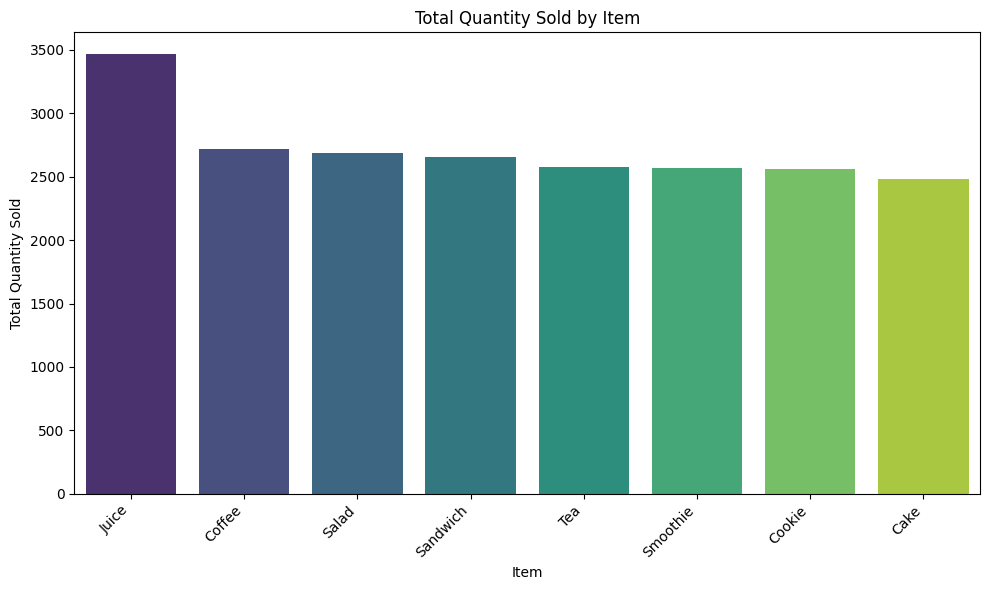

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Item', y='Quantity', data=total_quantity_by_item.sort_values(by='Quantity', ascending=False), hue='Item', legend=False, palette='viridis')

plt.title('Total Quantity Sold by Item')
plt.xlabel('Item')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [64]:
avg_total_spent_per_item = df.groupby('Item')['Total Spent'].mean().reset_index()
avg_total_spent_per_item.sort_values(by='Total Spent', ascending=False)

,Item,Total Spent
4,Salad,14.588432
5,Sandwich,11.899314
6,Smoothie,11.811543
0,Cake,8.960000
3,Juice,8.773738
1,Coffee,6.137931
7,Tea,4.732227
2,Cookie,3.301176


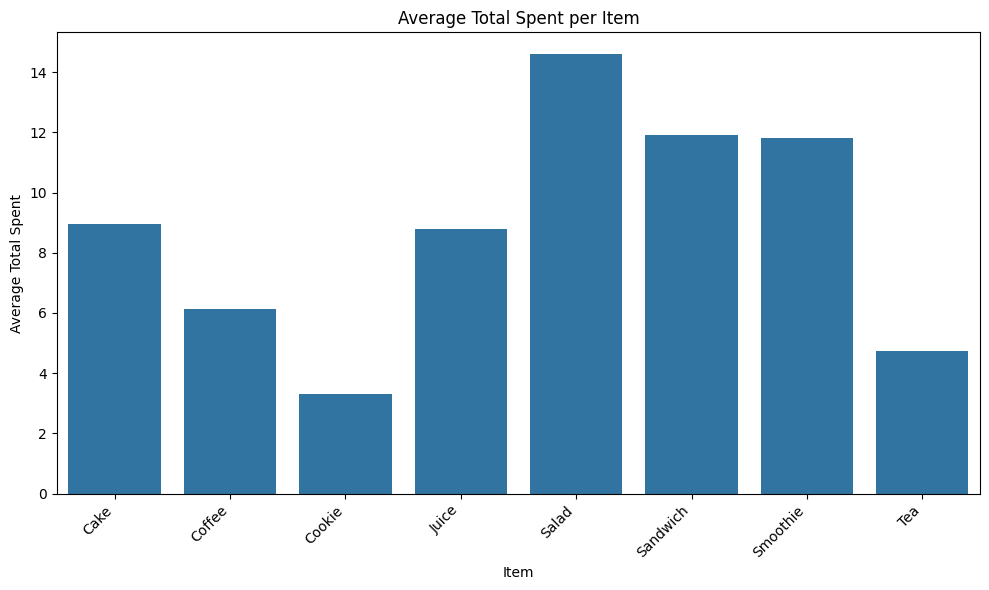

In [65]:
# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Item', y='Total Spent', data=avg_total_spent_per_item)

# Set title and labels
plt.title('Average Total Spent per Item')
plt.xlabel('Item')
plt.ylabel('Average Total Spent')

# Rotate x-axis labels if they are long
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

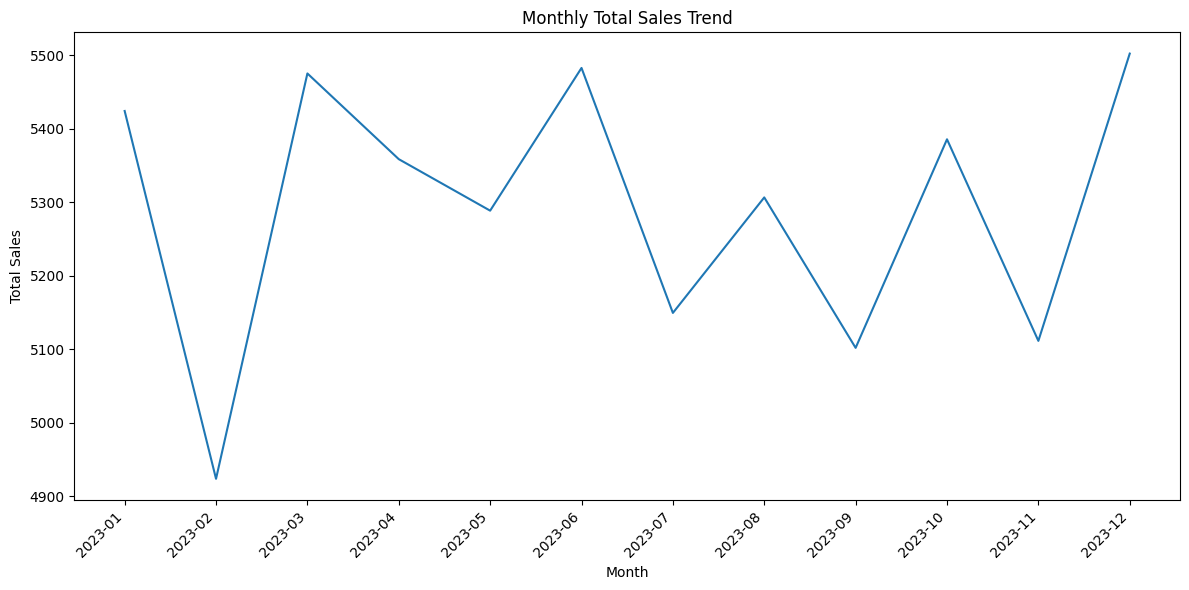

In [66]:
monthly_sales = df.groupby(['TD_year', 'TD_month'])['Total Spent'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['TD_year'].astype(int).astype(str) + '-' + monthly_sales['TD_month'].astype(int).astype(str).str.zfill(2)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Total Spent', data=monthly_sales)

plt.title('Monthly Total Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [69]:
total_spent_by_item = df.groupby('Item')['Total Spent'].sum().reset_index()
top_5_selling_items = total_spent_by_item.sort_values(by='Total Spent', ascending=False).head(5)
top_5_selling_items

,Item,Total Spent
4,Salad,13115.0
5,Sandwich,10400.0
3,Juice,10256.5
6,Smoothie,10028.0
0,Cake,7392.0


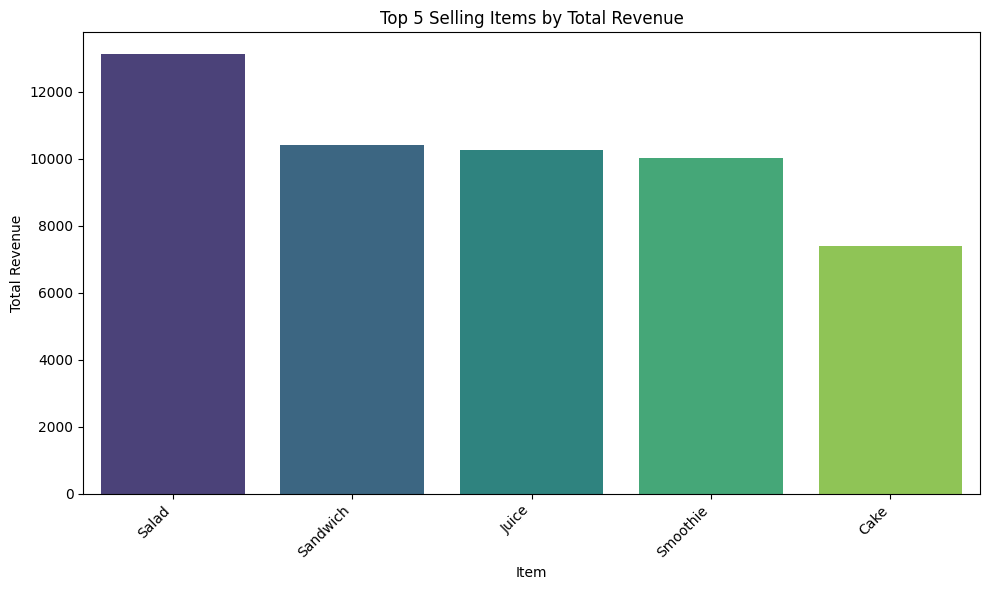

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Item', y='Total Spent', data=top_5_selling_items, hue='Item', legend=False, palette='viridis')

plt.title('Top 5 Selling Items by Total Revenue')
plt.xlabel('Item')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()